In [1]:
import torch
from torch.cuda.amp import autocast, GradScaler  
import torchvision
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm 

import os
from pathlib import Path
from typing import List, Tuple
import copy


In [2]:
os.chdir(r'C:\python\try_to_nn')

In [3]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
def count_params(model: torch.nn.Module):
    params_generator = model.parameters()
    return sum([p.numel() for p in params_generator])

#### Датакласс

In [5]:
from torch.utils.data import Dataset

class TinyImageNetDataset(Dataset):
    def __init__(self, split, root="./data/tiny-imagenet-200", transform=None, num_classes=10):
        super().__init__()
        self.root = root
        self.split = split
        self.transform = transform 
        self.classes = None

        wnids_path = self.root + "/wnids.txt"
        with open(wnids_path, mode='r', encoding='utf-8') as file:
            file = file.readlines()
            if num_classes:
                file = file[:num_classes]
            self.classes = {cls.strip(): i for i, cls in enumerate(file)}

        match split:
            case 'train':
                self._select_train_frames()
            case 'val':
                self._select_val_frames()
            case 'test':
                self._select_test_frames()
                
    def _select_train_frames(self, train_root: str = "train") -> List[Tuple[str, int]]:
        train_root = self.root + "/" + train_root
        samples = []
        for cls_name, cls_label in self.classes.items():
            cls_images_root = train_root + f'/{cls_name}' + '/images'
            cls_images_paths = os.listdir(cls_images_root)
            cls_images_paths = list(map(lambda x: cls_images_root + '/' + str(x), cls_images_paths))
            labels = [cls_label] * len(cls_images_paths)
            samples.extend(list(zip(cls_images_paths, labels)))
        self.samples = samples
    
    def _select_val_frames(self, val_root: str = "val", 
                           annotations_path: str = "val/val_annotations.txt") -> List[Tuple[str, int]]:
        val_root = self.root + "/" + val_root
        annotations_path = self.root + "/" + annotations_path
        images_path = val_root + '/images/'
        with open(annotations_path, mode='r', encoding='utf-8') as file:
            lines = file.readlines()
        self.samples = []
        for line in lines:
            parts = line.strip().split('\t')
            
            img_name = parts[0]
            cls_name = parts[1]
            
            if cls_name in self.classes:
                full_path = os.path.join(images_path, img_name)
                label = self.classes[cls_name]
                self.samples.append((full_path, label))       
            
    def _select_test_frames(self, test_root: str = "test/images/") -> List[Tuple[str, int]]:
        test_root = self.root + "/" + test_root
        images = os.listdir(test_root)
        images = list(map(lambda x: test_root + str(x), images))
        labels = [-1]*len(images)
        self.samples = list(zip(images, labels))

    def __len__(self):
        return len(self.samples)
    
    def _load_image(self, img_path: str):
        with open(img_path, mode='rb') as file:
            image = Image.open(file)
            return image.convert(mode='RGB')
    
    def __getitem__(self, index):
        image_path, image_label = self.samples[index]

        image = self._load_image(image_path)
        if self.transform:
            image = self.transform(image)

        return image, image_label
        




#### Приводим к разрешению 128 на 128

In [6]:
import cv2
from PIL.Image import Resampling

pict_path = './data/tiny-imagenet-200/val/images/val_0.JPEG'
with open(pict_path, mode='rb') as file:
    img = Image.open(file)
    print(img.size)
    img = img.resize((128, 128), resample=Resampling.BICUBIC)
    print(img.size)
    img.show()


(64, 64)
(128, 128)


### Классификатор: архитектура

##### MBConv Block

In [7]:
from torch import nn

class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expansion_rate=1, stride=1, kernel_size=3):
        super().__init__()
    
        self.skip_connection = (stride == 1) and (in_channels == out_channels)
        expanded_channels = in_channels * expansion_rate
        padding_val = (kernel_size - 1) // 2
        squeeze_channels = max(1, expanded_channels // 4)

        self.expantion = nn.Identity()
        if expansion_rate != 1:
            self.expantion = nn.Sequential(
                nn.Conv2d(in_channels, expanded_channels, 
                          kernel_size=1, padding=0, bias=False),
                nn.BatchNorm2d(expanded_channels),
                nn.SiLU(inplace=True)
            )

        self.depthwize_convolution = nn.Sequential(
            nn.Conv2d(expanded_channels, expanded_channels, 
                      kernel_size=kernel_size, stride=stride, padding=padding_val, groups=expanded_channels, bias=False),
            nn.BatchNorm2d(expanded_channels),
            nn.SiLU(inplace=True)
        )

        self.SE_block = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=(1, 1)),
            nn.Conv2d(
                in_channels=expanded_channels, out_channels=squeeze_channels, kernel_size=1
            ),
            nn.SiLU(inplace=True),
            nn.Conv2d(
                in_channels=squeeze_channels, out_channels=expanded_channels, kernel_size=1
            ),
            nn.Sigmoid()
        )

        self.projection = nn.Sequential(
            nn.Conv2d(in_channels=expanded_channels, out_channels=out_channels, kernel_size=1, padding=0, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        
    def forward(self, x):
        input = x
        output = self.expantion(x)
        output = self.depthwize_convolution(output)
        output = self.SE_block(output) * output
        output = self.projection(output) 
        if self.skip_connection:
            output += input

        return output


In [8]:
class ClassificationNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(
            in_channels=3, out_channels=64, kernel_size=3, padding=1, bias=False
            ),
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True)
        )

        self.MBC1 = MBConvBlock(in_channels=64, out_channels=128, expansion_rate=1, stride=2, kernel_size=3)
        self.MBC2 = MBConvBlock(in_channels=128, out_channels=128, expansion_rate=6, stride=2, kernel_size=5)
        self.MBC3 = MBConvBlock(in_channels=128, out_channels=128, expansion_rate=6, stride=1, kernel_size=5)

        self.conv2 = nn.Sequential(
            nn.Conv2d(
            in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm2d(256),
            nn.SiLU(inplace=True)
        )
        self.gap = nn.AdaptiveAvgPool2d(output_size=1)
        self.fc = nn.Linear(256, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.MBC1(x)
        x = self.MBC2(x)
        x = self.MBC3(x)
        x = self.conv2(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x


In [9]:
from torchvision import transforms


train_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.BICUBIC),  
    transforms.RandomHorizontalFlip(p=0.5),  
    transforms.RandomRotation(degrees=15),  
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = TinyImageNetDataset(split='train', root='./data/tiny-imagenet-200', transform=train_transform)
val_dataset = TinyImageNetDataset(split='val', root='./data/tiny-imagenet-200', transform=val_transform)
test_dataset = TinyImageNetDataset(split='test', root='./data/tiny-imagenet-200', transform=val_transform)

In [10]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

In [11]:

def train_net(model, optimizer, loss_func, train_dataloader, val_dataloader, num_epoch=5):
    model.to(device)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    train_loss_history = []
    train_accuracy_history = []
    val_loss_history = []
    val_accuracy_history = []
    scaler = GradScaler()

    for epoch in tqdm(range(num_epoch), desc="Training"):
        model.train()
        
        running_train_loss = 0.0
        running_train_acc = 0.0
        
        for i, train_batch in enumerate(train_dataloader):
            x_train_batch, y_train_batch = train_batch[0].to(device), train_batch[1].to(device)
            
            optimizer.zero_grad(set_to_none=True)
            
            with autocast():
                logits = model(x_train_batch)
                loss = loss_func(logits, y_train_batch)
            
            scaler.scale(loss).backward()
            
            scaler.step(optimizer)
            
            scaler.update()
            
            predicted_classes = torch.argmax(logits, dim=1)
            acc = (predicted_classes == y_train_batch).float().mean().item()
            
            running_train_loss += loss.item()
            running_train_acc += acc
            
        epoch_avg_train_loss = running_train_loss / len(train_dataloader)
        epoch_avg_train_acc = running_train_acc / len(train_dataloader)
        
        train_loss_history.append(epoch_avg_train_loss)
        train_accuracy_history.append(epoch_avg_train_acc)

        with torch.no_grad():
            model.eval()
            running_val_loss = 0.0
            running_val_acc = 0.0
            
            for j, val_batch in enumerate(val_dataloader):
                x_val_batch, y_val_batch = val_batch[0].to(device), val_batch[1].to(device)
            
                with autocast():
                    val_logits = model(x_val_batch)
                    val_loss = loss_func(val_logits, y_val_batch)

                predicted_classes = torch.argmax(val_logits, dim=1)
                val_acc = (predicted_classes == y_val_batch).float().mean().item()

                running_val_loss += val_loss.item()
                running_val_acc += val_acc
        
        epoch_avg_val_loss = running_val_loss / len(val_dataloader)
        epoch_avg_val_acc = running_val_acc / len(val_dataloader)

        if epoch_avg_val_acc > best_acc:
            best_acc = epoch_avg_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        val_loss_history.append(epoch_avg_val_loss)
        val_accuracy_history.append(epoch_avg_val_acc)
        
    model.load_state_dict(best_model_wts)
    return {
        'train': {
            'loss': train_loss_history,
            'accuracy': train_accuracy_history
        },
        'val': {
            'loss': val_loss_history,
            'accuracy': val_accuracy_history
        }
    }

In [12]:
def plot_training_results(history):

    train_loss = history['train']['loss']
    val_loss = history['val']['loss']
    train_acc = history['train']['accuracy']
    val_acc = history['val']['accuracy']
    

    if len(train_loss) > 0 and isinstance(train_loss[0], torch.Tensor):
        train_loss = [x.detach().cpu().item() for x in train_loss]
        val_loss = [x.detach().cpu().item() for x in val_loss]
        
    if len(train_acc) > 0 and isinstance(train_acc[0], torch.Tensor):
        train_acc = [x.detach().cpu().item() for x in train_acc]
        val_acc = [x.detach().cpu().item() for x in val_acc]

    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
    plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
    plt.title('Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, 'b-o', label='Train Loss')
    plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def print_model_info(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print("\nModel Architecture:")
    print(model)

In [13]:
model = ClassificationNet()
device = device
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0001, weight_decay=3e-4)
loss_func = torch.nn.CrossEntropyLoss()

In [20]:
metrics_classification_net = train_net(model, optimizer, loss_func, train_dataloader, val_dataloader, num_epoch=35)

C:\Users\Максим\AppData\Local\Temp\ipykernel_3628\1246563154.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Training:   0%|          | 0/35 [00:00<?, ?it/s]C:\Users\Максим\AppData\Local\Temp\ipykernel_3628\1246563154.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Максим\AppData\Local\Temp\ipykernel_3628\1246563154.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Training: 100%|██████████| 35/35 [1:01:13<00:00, 104.95s/it]


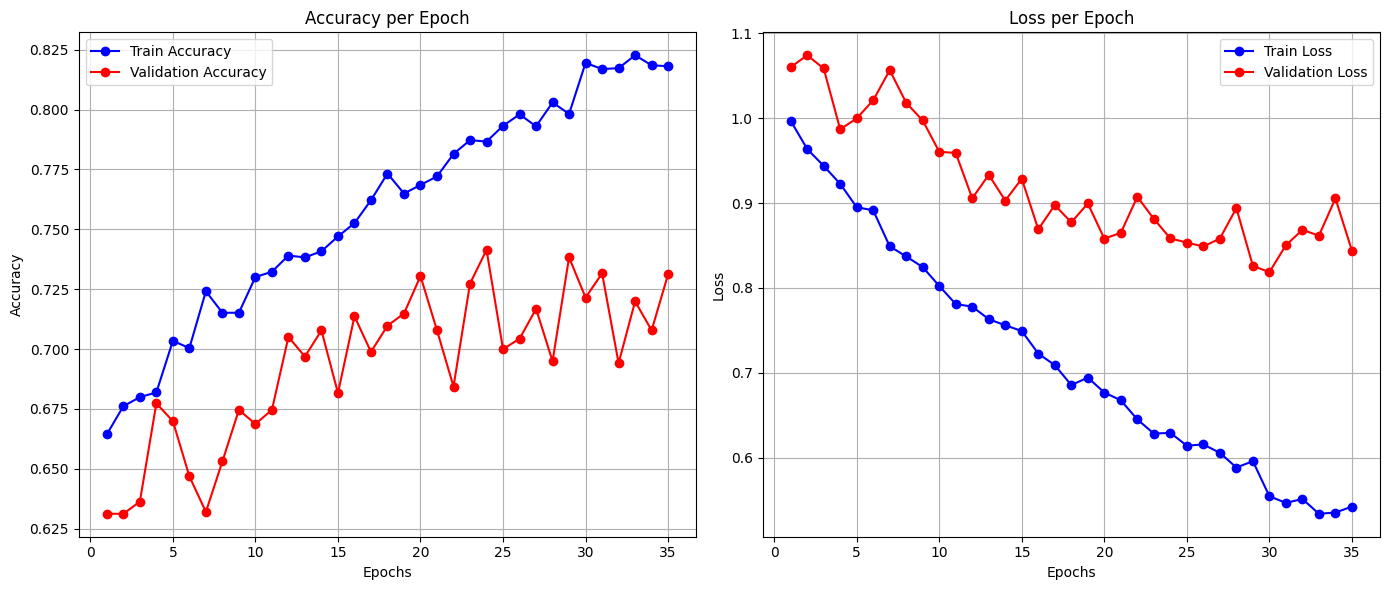

In [21]:
plot_training_results(metrics_classification_net)

In [14]:
count_params(model)

1341146

In [22]:
torch.save(model.state_dict(), 'classification_net.pth')

### U-Net

In [14]:
class MoonDataset(Dataset):
    def __init__(self, root_dir, split="train", img_size=128, transform=None):
        self.root_dir = root_dir
        self.split = split
        self.img_size = img_size
        self.transform = transform
        
        self.images_dir = os.path.join(root_dir, 'images', 'render')
        self.masks_dir = os.path.join(root_dir, 'images', 'ground')
        
        self.filenames = [f for f in os.listdir(self.images_dir) if f.endswith('.png') or f.endswith('.jpg')]
        self.filenames.sort()
        
        val_size = int(len(self.filenames) * 0.2)
        if split == "train":
            self.filenames = self.filenames[val_size:]
        else:
            self.filenames = self.filenames[:val_size]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx] 
        

        mask_name = img_name.replace('render', 'ground') 
        
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, mask_name)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)

        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.functional.to_tensor(image)

        mask = torch.from_numpy(np.array(mask)).float()
        mask = mask / 255.0
        mask = (mask > 0.5).float()
        mask = mask.unsqueeze(0)

        return image, mask

In [15]:
train_transforms = transforms.Compose([
    # transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_ds = MoonDataset(root_dir='./data/MOON_SEGMENTATION_BINARY', split="train", transform=train_transforms)
val_ds = MoonDataset(root_dir='./data/MOON_SEGMENTATION_BINARY', split="val", transform=val_transforms)

In [16]:
train_loader_unet = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader_unet = DataLoader(val_ds, batch_size=32, shuffle=False)

##### Архитектура U-Net

In [17]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [18]:
class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super(UNet, self).__init__()
        
        self.enc1 = DoubleConv(n_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        
        self.pool = nn.MaxPool2d(2) 
        self.bottleneck = DoubleConv(256, 512)
        
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256) 
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64) 

        self.out = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        x = self.pool(e1)

        e2 = self.enc2(x)
        x = self.pool(e2)

        e3 = self.enc3(x)
        x = self.pool(e3)

        x = self.bottleneck(x)

        x = self.up3(x)
        x = torch.cat([e3, x], dim=1) 
        x = self.dec3(x)

        x = self.up2(x)
        x = torch.cat([e2, x], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([e1, x], dim=1)
        x = self.dec1(x)

        return self.out(x)

In [19]:
def train_stable(model, optimizer, loss_func, train_loader, val_loader, num_epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'val_dice': []}
        
    for epoch in range(num_epochs):
        model.train()
        train_loss_accum = 0
        
        for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            
            logits = model(x)
            loss = loss_func(logits, y)
            
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss_accum += loss.item()
            
        model.eval()
        val_loss_accum = 0
        val_dice_accum = 0
        
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                
                logits = model(x)
                loss = loss_func(logits, y)
                val_loss_accum += loss.item()
                
                # Метрика Dice
                preds = (torch.sigmoid(logits) > 0.5).float()
                intersection = (preds * y).sum()
                dice = (2. * intersection) / (preds.sum() + y.sum() + 1e-6)
                val_dice_accum += dice.item()
        
        avg_train_loss = train_loss_accum / len(train_loader)
        avg_val_loss = val_loss_accum / len(val_loader)
        avg_val_dice = val_dice_accum / len(val_loader)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_dice'].append(avg_val_dice)
        
        print(f"Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")
        
    return history

In [20]:
def plot_training_results(history):
    """
    Визуализация лоссов и метрики Dice.
    """
    train_loss = history.get('train_loss', [])
    val_loss = history.get('val_loss', [])
    val_dice = history.get('val_dice', [])
    
    train_dice = history.get('train_dice', None) 

    if len(train_loss) > 0 and isinstance(train_loss[0], torch.Tensor):
        train_loss = [x.detach().cpu().item() for x in train_loss]
        val_loss = [x.detach().cpu().item() for x in val_loss]
        val_dice = [x.detach().cpu().item() for x in val_dice]

    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'b-o', label='Train Loss')
    plt.plot(epochs, val_loss, 'r-o', label='Val Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    if train_dice:
        plt.plot(epochs, train_dice, 'b-o', label='Train Dice')
    plt.plot(epochs, val_dice, 'g-o', label='Val Dice')
    plt.title('Dice Score per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_unet = UNet(n_channels=3, n_classes=1).to(device)
optimizer = torch.optim.Adam(model_unet.parameters(), lr=1e-4)
loss_func = torch.nn.BCEWithLogitsLoss()

In [52]:
metrics_unet = train_stable(model_unet, optimizer, loss_func, train_loader_unet, val_loader_unet, num_epochs=25)

Epoch 1/25: 100%|██████████| 25/25 [00:44<00:00,  1.78s/it]


Loss: 0.2448 | Val Loss: 0.2237 | Val Dice: 0.4820


Epoch 2/25: 100%|██████████| 25/25 [00:44<00:00,  1.78s/it]


Loss: 0.2301 | Val Loss: 0.3159 | Val Dice: 0.4585


Epoch 3/25: 100%|██████████| 25/25 [00:44<00:00,  1.77s/it]


...

Loss: 0.1811 | Val Loss: 0.1988 | Val Dice: 0.4682


Epoch 24/25: 100%|██████████| 25/25 [00:44<00:00,  1.78s/it]


Loss: 0.1861 | Val Loss: 0.1759 | Val Dice: 0.6087


Epoch 25/25: 100%|██████████| 25/25 [00:44<00:00,  1.76s/it]


Loss: 0.1825 | Val Loss: 0.1859 | Val Dice: 0.5002


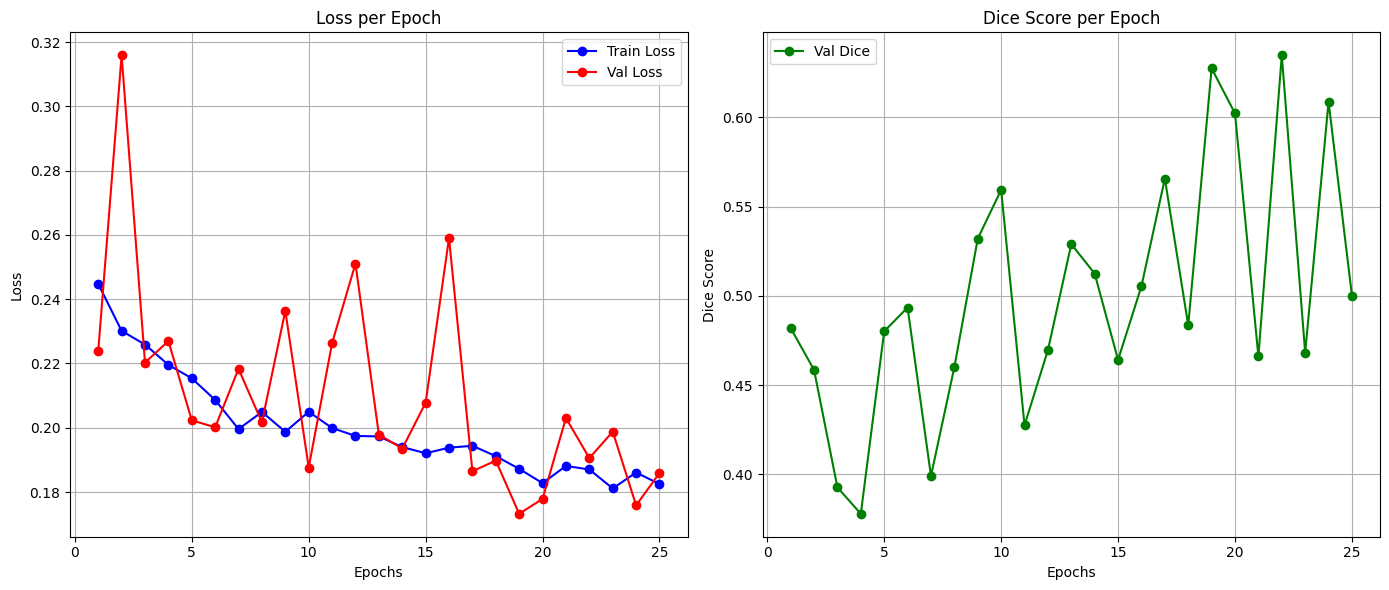

In [53]:
plot_training_results(metrics_unet)

In [54]:
torch.save(model_unet, 'unet_simple.pth')

####  Unet + backbone из первого классификатора

In [22]:
class UNetWithBackbone(nn.Module):
    def __init__(self, backbone, n_classes=1):
        super().__init__()

        self.backbone = backbone

        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(256, 128)
    
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(192, 64)

        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(96, 32)
        
        self.final = nn.Conv2d(32, n_classes, kernel_size=1)
        
    def forward(self, x):

        x1 = self.backbone.conv1(x)
        x2 = self.backbone.MBC1(x1)
        x3 = self.backbone.MBC2(x2)
        x3_refined = self.backbone.MBC3(x3)
        
        bottleneck = self.backbone.conv2(x3_refined)
    
        u1 = self.up1(bottleneck)
        cat1 = torch.cat([x3_refined, u1], dim=1) 
        d1 = self.dec1(cat1)
        u2 = self.up2(d1)
        cat2 = torch.cat([x2, u2], dim=1)
        d2 = self.dec2(cat2)
        u3 = self.up3(d2)
        cat3 = torch.cat([x1, u3], dim=1)
        d3 = self.dec3(cat3)
        
        return self.final(d3)

In [23]:
def freeze_backbone(model):
    """Замораживает веса энкодера (из классификатора)"""
    for param in model.backbone.parameters():
        param.requires_grad = False

def unfreeze_all(model):
    """Размораживает всю модель """
    for param in model.parameters():
        param.requires_grad = True


In [24]:
classifier = ClassificationNet()
classifier.load_state_dict(torch.load(r'C:\python\try_to_nn\CV_ITMO\HW_03\Encoder_part\classification_net.pth')) 

<All keys matched successfully>

In [25]:
model_backbone = UNetWithBackbone(classifier, n_classes=1).to(device)

In [27]:
freeze_backbone(model_backbone)

optimizer_a = torch.optim.Adam(filter(lambda p: p.requires_grad, model_backbone.parameters()), lr=1e-3)

history_a = train_stable(model_backbone, optimizer_a, loss_func, train_loader_unet, val_loader_unet, num_epochs=5)

unfreeze_all(model_backbone)

optimizer_b = torch.optim.Adam(model_backbone.parameters(), lr=1e-4)

history_b = train_stable(model_backbone, optimizer_b, loss_func, train_loader_unet, val_loader_unet, num_epochs=20)

Epoch 1/5: 100%|██████████| 25/25 [00:14<00:00,  1.70it/s]


Loss: 0.4296 | Val Loss: 0.3578 | Val Dice: 0.5055


Epoch 2/5: 100%|██████████| 25/25 [00:14<00:00,  1.78it/s]


Loss: 0.3383 | Val Loss: 0.2878 | Val Dice: 0.5356


Epoch 3/5: 100%|██████████| 25/25 [00:14<00:00,  1.76it/s]


...

Loss: 0.1644 | Val Loss: 0.1772 | Val Dice: 0.6478


Epoch 19/20: 100%|██████████| 25/25 [05:30<00:00, 13.20s/it]


Loss: 0.1621 | Val Loss: 0.1740 | Val Dice: 0.6314


Epoch 20/20: 100%|██████████| 25/25 [05:29<00:00, 13.20s/it]


Loss: 0.1596 | Val Loss: 0.1765 | Val Dice: 0.6485


In [28]:
metrics_backbone = {**history_a, **history_b}

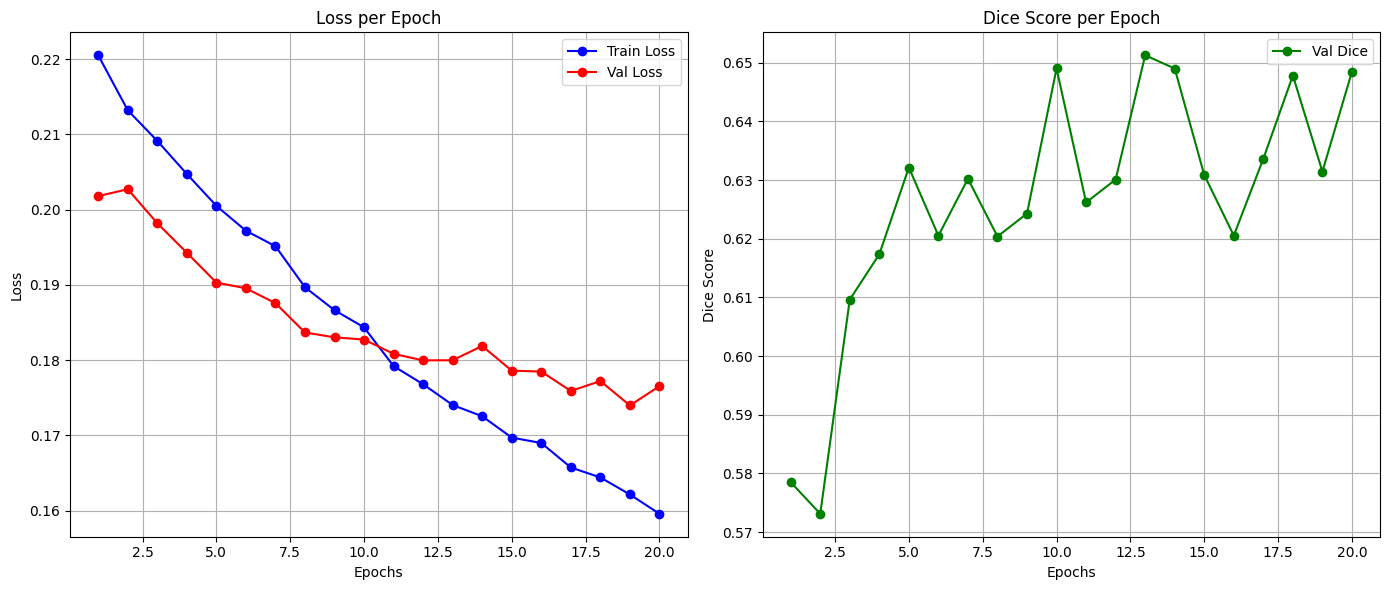

In [29]:
plot_training_results(metrics_backbone)

In [30]:
torch.save(model_backbone, "unet_with_backbone.pth")